# ML-Based Sentiment Analyzer
## Train on Twitter Data & Analyze User Text

This notebook demonstrates:
- Loading Twitter CSV data
- Training 4 ML models (Logistic Regression, Naive Bayes, Random Forest, Gradient Boosting)
- Analyzing user input text
- Getting sentiment predictions with confidence scores
- Ensemble voting for consensus

## 1. Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")

✅ All libraries imported!


## 2. Load and Prepare Data

In [8]:
# Load your Twitter CSV file
file_path = r"D:\Projects\CodeAlpha\Sentiment Analysis\simple_results.csv"  # Change this path

df = pd.read_csv(file_path)
print(f"✅ Loaded {len(df)} records")

# Display basic info
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())

# Display sentiment distribution
print(f"\n📊 Sentiment Distribution:")
print(df['sentiment'].value_counts())

✅ Loaded 100 records

Column names: ['tweet', 'sentiment', 'score']

First few rows:
                                               tweet sentiment     score
0  when modi promised “minimum government maximum...  negative -0.300000
1  talk all the nonsense and continue all the dra...   neutral  0.000000
2  what did just say vote for modi  welcome bjp t...  positive  0.483333
3  asking his supporters prefix chowkidar their n...  positive  0.150000
4  answer who among these the most powerful world...  positive  0.400000

📊 Sentiment Distribution:
sentiment
neutral     51
positive    34
negative    15
Name: count, dtype: int64


## 3. Data Preparation

In [9]:
# Column names
text_column = 'tweet'  # Change if different
label_column = 'sentiment'  # Change if different

# Clean data
df = df.dropna(subset=[text_column, label_column])
print(f"✅ After cleaning: {len(df)} records")

# Prepare data
texts = df[text_column].astype(str).values
labels = df[label_column].values

# Create label mapping
unique_labels = sorted(df[label_column].unique())
label_map = {label: i for i, label in enumerate(unique_labels)}
reverse_label_map = {v: k for k, v in label_map.items()}

print(f"\n🏷️ Label Mapping: {label_map}")

numeric_labels = np.array([label_map[label] for label in labels])

print(f"\nData prepared: {len(texts)} texts, {len(unique_labels)} classes")

✅ After cleaning: 100 records

🏷️ Label Mapping: {'negative': 0, 'neutral': 1, 'positive': 2}

Data prepared: 100 texts, 3 classes


## 4. Vectorize Text (TF-IDF)

In [10]:
print("📝 Vectorizing text using TF-IDF...")

vectorizer = TfidfVectorizer(
    max_features=5000,      # Keep 5000 most important words
    min_df=2,               # Ignore words appearing in <2 docs
    max_df=0.8,             # Ignore words appearing in >80% docs
    ngram_range=(1, 2),     # Use single and paired words
    stop_words='english',   # Remove common English words
    lowercase=True          # Convert to lowercase
)

X = vectorizer.fit_transform(texts)
print(f"✅ Created {X.shape[1]} features from {X.shape[0]} texts")
print(f"\nFeature matrix shape: {X.shape}")
print(f"Sparsity: {1.0 - (X.nnz / (X.shape[0] * X.shape[1]))*100:.2f}%")

📝 Vectorizing text using TF-IDF...
✅ Created 72 features from 100 texts

Feature matrix shape: (100, 72)
Sparsity: -2.18%


## 5. Split Data

In [11]:
print("📊 Splitting data (80% train, 20% test)...\n")

X_train, X_test, y_train, y_test = train_test_split(
    X, numeric_labels,
    test_size=0.2,
    random_state=42,
    stratify=numeric_labels
)

print(f"✅ Train set: {len(y_train)} samples")
print(f"✅ Test set: {len(y_test)} samples")

print(f"\nLabel distribution in training set:")
for label, count in zip(*np.unique(y_train, return_counts=True)):
    print(f"  {reverse_label_map[label]}: {count}")

📊 Splitting data (80% train, 20% test)...

✅ Train set: 80 samples
✅ Test set: 20 samples

Label distribution in training set:
  negative: 12
  neutral: 41
  positive: 27


## 6. Train 4 ML Models

In [12]:
print("🤖 TRAINING 4 ML MODELS\n")
print("="*70)

models = {}
results = {}

model_configs = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

for model_name, model in model_configs.items():
    print(f"\n⏳ Training {model_name}...")
    
    # Train
    model.fit(X_train, y_train)
    models[model_name] = model
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_weighted')
    
    results[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std()
    }
    
    print(f"✅ {model_name}")
    print(f"   Accuracy:  {accuracy:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    print(f"   CV Score:  {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print("\n" + "="*70)

🤖 TRAINING 4 ML MODELS


⏳ Training Logistic Regression...
✅ Logistic Regression
   Accuracy:  0.5000
   F1-Score:  0.5007
   CV Score:  0.3463 ± 0.0464

⏳ Training Naive Bayes...
✅ Naive Bayes
   Accuracy:  0.6000
   F1-Score:  0.5350
   CV Score:  0.3453 ± 0.0474

⏳ Training Random Forest...
✅ Random Forest
   Accuracy:  0.4500
   F1-Score:  0.4500
   CV Score:  0.3664 ± 0.0552

⏳ Training Gradient Boosting...
✅ Gradient Boosting
   Accuracy:  0.4500
   F1-Score:  0.4500
   CV Score:  0.3768 ± 0.0666



## 7. Compare Models

In [13]:
# Create comparison dataframe
comparison_df = pd.DataFrame(results).T

print("\n📊 MODEL COMPARISON")
print("="*70)
print("\n" + comparison_df.to_string())

# Find best model
best_model_name = comparison_df['F1-Score'].idxmax()
best_model = models[best_model_name]

print(f"\n\n🏆 BEST MODEL: {best_model_name}")
print(f"   F1-Score: {comparison_df.loc[best_model_name, 'F1-Score']:.4f}")


📊 MODEL COMPARISON

                     Accuracy  Precision  Recall  F1-Score   CV Mean    CV Std
Logistic Regression      0.50   0.553977    0.50  0.500714  0.346315  0.046420
Naive Bayes              0.60   0.510000    0.60  0.535000  0.345343  0.047419
Random Forest            0.45   0.456250    0.45  0.450000  0.366394  0.055240
Gradient Boosting        0.45   0.475714    0.45  0.450000  0.376838  0.066622


🏆 BEST MODEL: Naive Bayes
   F1-Score: 0.5350


## 8. Visualize Results

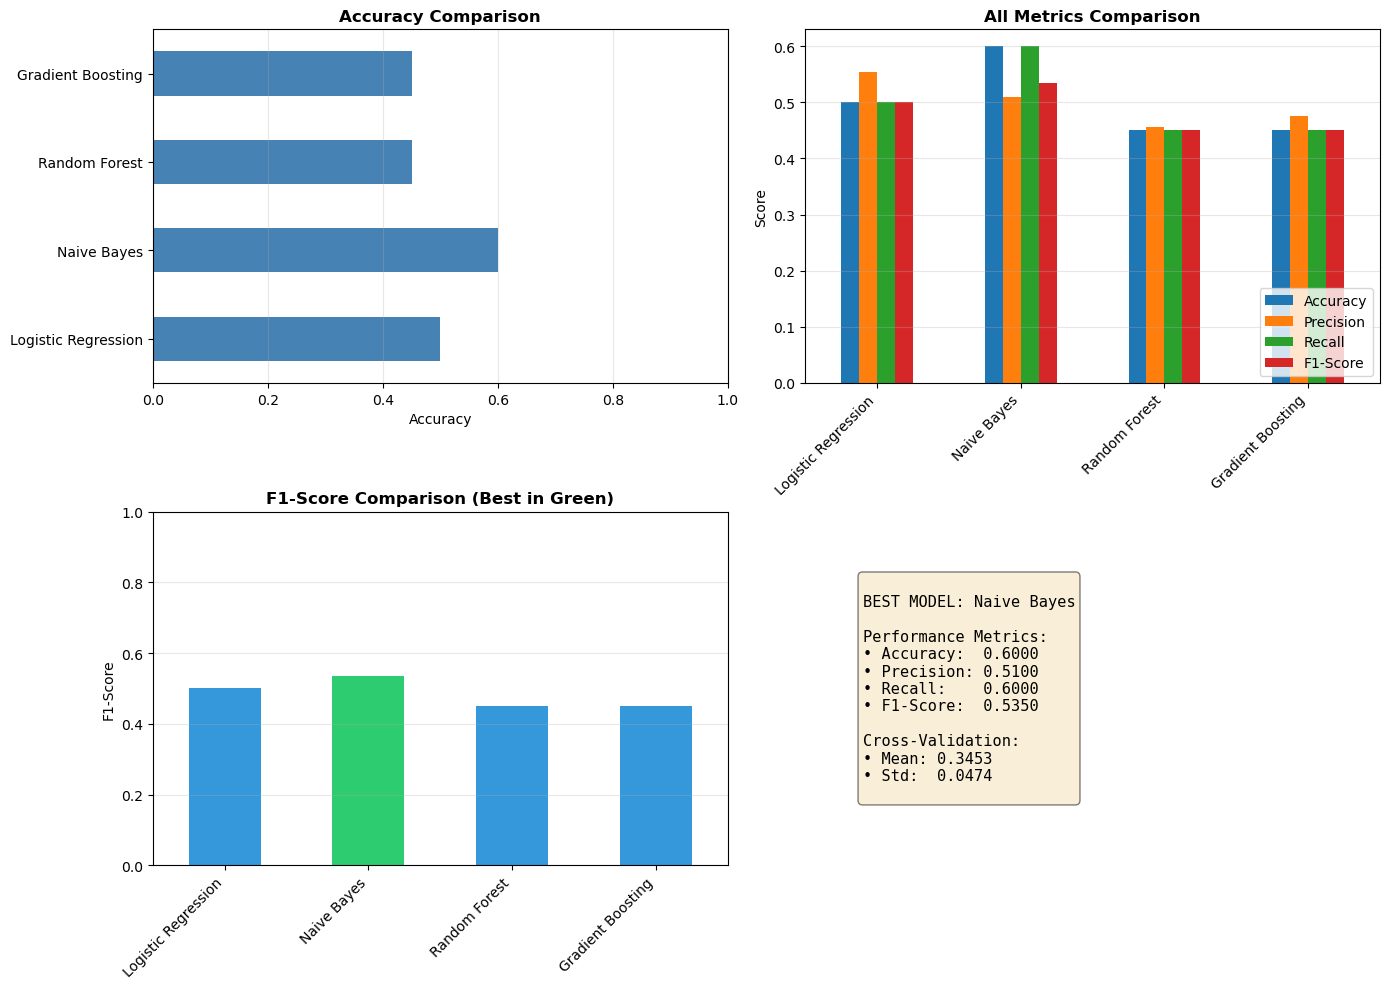

✅ Visualizations displayed!


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Accuracy comparison
ax1 = axes[0, 0]
comparison_df['Accuracy'].plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_xlabel('Accuracy')
ax1.set_title('Accuracy Comparison', fontweight='bold')
ax1.set_xlim(0, 1)
ax1.grid(axis='x', alpha=0.3)

# 2. All metrics
ax2 = axes[0, 1]
comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', ax=ax2)
ax2.set_title('All Metrics Comparison', fontweight='bold')
ax2.set_ylabel('Score')
ax2.legend(loc='lower right')
ax2.grid(axis='y', alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 3. F1-Score
ax3 = axes[1, 0]
colors = ['#2ecc71' if name == best_model_name else '#3498db' for name in comparison_df.index]
comparison_df['F1-Score'].plot(kind='bar', ax=ax3, color=colors)
ax3.set_title('F1-Score Comparison (Best in Green)', fontweight='bold')
ax3.set_ylabel('F1-Score')
ax3.set_ylim(0, 1)
ax3.grid(axis='y', alpha=0.3)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 4. Summary
ax4 = axes[1, 1]
ax4.axis('off')
summary_text = f"""
BEST MODEL: {best_model_name}

Performance Metrics:
• Accuracy:  {comparison_df.loc[best_model_name, 'Accuracy']:.4f}
• Precision: {comparison_df.loc[best_model_name, 'Precision']:.4f}
• Recall:    {comparison_df.loc[best_model_name, 'Recall']:.4f}
• F1-Score:  {comparison_df.loc[best_model_name, 'F1-Score']:.4f}

Cross-Validation:
• Mean: {comparison_df.loc[best_model_name, 'CV Mean']:.4f}
• Std:  {comparison_df.loc[best_model_name, 'CV Std']:.4f}
"""
ax4.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        verticalalignment='center')

plt.tight_layout()
plt.show()

print("✅ Visualizations displayed!")

## 9. Analyze User Input Text

In [16]:
def analyze_text(text, models, vectorizer, reverse_label_map, best_model_name):
    """Analyze sentiment of input text using all models"""
    print(f"\n{'='*70}")
    print(f"📝 ANALYZING TEXT")
    print(f"{'='*70}")
    print(f"\nText: \"{text}\"\n")
    
    # Vectorize
    X = vectorizer.transform([text])
    
    results = []
    
    print("📊 RESULTS FROM EACH MODEL:")
    print("-"*70)
    
    for i, (model_name, model) in enumerate(models.items(), 1):
        # Predict
        pred = model.predict(X)[0]
        proba = model.predict_proba(X)[0] if hasattr(model, 'predict_proba') else None
        confidence = max(proba) if proba is not None else 0
        
        # Get sentiment label
        sentiment = reverse_label_map.get(pred, str(pred))
        
        results.append({
            'model': model_name,
            'sentiment': sentiment,
            'confidence': confidence
        })
        
        # Get emoji
        sentiment_lower = sentiment.lower()
        if 'positive' in sentiment_lower:
            emoji = "😊"
        elif 'negative' in sentiment_lower:
            emoji = "😞"
        else:
            emoji = "😐"
        
        is_best = " ⭐ BEST" if model_name == best_model_name else ""
        print(f"\n{i}. {model_name}{is_best}")
        print(f"   {emoji} Sentiment: {sentiment.upper()}")
        print(f"   📈 Confidence: {confidence:.2%}")
    
    # Consensus
    print(f"\n{'-'*70}")
    print(f"🎯 ENSEMBLE VOTING (Consensus):")
    print("-"*70)
    
    sentiments = [r['sentiment'] for r in results]
    consensus = max(set(sentiments), key=sentiments.count)
    consensus_count = sentiments.count(consensus)
    
    sentiment_lower = consensus.lower()
    if 'positive' in sentiment_lower:
        emoji = "😊"
    elif 'negative' in sentiment_lower:
        emoji = "😞"
    else:
        emoji = "😐"
    
    print(f"\n{emoji} Consensus Sentiment: {consensus.upper()}")
    print(f"📊 Agreement: {consensus_count}/{len(sentiments)} models ({consensus_count/len(sentiments)*100:.0f}%)")
    
    # Best model
    print(f"\n{'-'*70}")
    print(f"🏆 BEST MODEL PREDICTION ({best_model_name}):")
    print("-"*70)
    best_result = next(r for r in results if r['model'] == best_model_name)
    sentiment_lower = best_result['sentiment'].lower()
    if 'positive' in sentiment_lower:
        emoji = "😊"
    elif 'negative' in sentiment_lower:
        emoji = "😞"
    else:
        emoji = "😐"
    print(f"\n{emoji} Sentiment: {best_result['sentiment'].upper()}")
    print(f"📈 Confidence: {best_result['confidence']:.2%}")

# Test on sample texts
test_texts = [
    "I absolutely love this product! It's amazing!",
    "This is terrible. Worst experience ever.",
    "It's okay, nothing special.",
    "Best day of my life! So happy!",
    "Disappointed with the quality."
]

for text in test_texts:
    analyze_text(text, models, vectorizer, reverse_label_map, best_model_name)
    print("\n\n")


📝 ANALYZING TEXT

Text: "I absolutely love this product! It's amazing!"

📊 RESULTS FROM EACH MODEL:
----------------------------------------------------------------------

1. Logistic Regression
   😐 Sentiment: NEUTRAL
   📈 Confidence: 54.50%

2. Naive Bayes ⭐ BEST
   😐 Sentiment: NEUTRAL
   📈 Confidence: 51.25%

3. Random Forest
   😐 Sentiment: NEUTRAL
   📈 Confidence: 58.20%

4. Gradient Boosting
   😐 Sentiment: NEUTRAL
   📈 Confidence: 64.02%

----------------------------------------------------------------------
🎯 ENSEMBLE VOTING (Consensus):
----------------------------------------------------------------------

😐 Consensus Sentiment: NEUTRAL
📊 Agreement: 4/4 models (100%)

----------------------------------------------------------------------
🏆 BEST MODEL PREDICTION (Naive Bayes):
----------------------------------------------------------------------

😐 Sentiment: NEUTRAL
📈 Confidence: 51.25%




📝 ANALYZING TEXT

Text: "This is terrible. Worst experience ever."

📊 RESULTS FROM 

## 10. Interactive Analysis (Try Your Own Text)

In [17]:
# Enter your own text here
user_text = "I really enjoy using this service! Great quality and fast delivery."

analyze_text(user_text, models, vectorizer, reverse_label_map, best_model_name)


📝 ANALYZING TEXT

Text: "I really enjoy using this service! Great quality and fast delivery."

📊 RESULTS FROM EACH MODEL:
----------------------------------------------------------------------

1. Logistic Regression
   😐 Sentiment: NEUTRAL
   📈 Confidence: 70.48%

2. Naive Bayes ⭐ BEST
   😐 Sentiment: NEUTRAL
   📈 Confidence: 66.35%

3. Random Forest
   😐 Sentiment: NEUTRAL
   📈 Confidence: 76.62%

4. Gradient Boosting
   😐 Sentiment: NEUTRAL
   📈 Confidence: 85.80%

----------------------------------------------------------------------
🎯 ENSEMBLE VOTING (Consensus):
----------------------------------------------------------------------

😐 Consensus Sentiment: NEUTRAL
📊 Agreement: 4/4 models (100%)

----------------------------------------------------------------------
🏆 BEST MODEL PREDICTION (Naive Bayes):
----------------------------------------------------------------------

😐 Sentiment: NEUTRAL
📈 Confidence: 66.35%


## 11. Save Models for Future Use

In [18]:
import pickle

# Save all models
model_data = {
    'models': models,
    'vectorizer': vectorizer,
    'label_map': label_map,
    'reverse_label_map': reverse_label_map,
    'best_model_name': best_model_name,
    'comparison_results': results
}

with open('sentiment_models.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("✅ Models saved to: sentiment_models.pkl")

# How to load and use later:
print("\n📝 To load and use later:")
print("""
with open('sentiment_models.pkl', 'rb') as f:
    data = pickle.load(f)
    models = data['models']
    vectorizer = data['vectorizer']
    # ... analyze new text
""")

✅ Models saved to: sentiment_models.pkl

📝 To load and use later:

with open('sentiment_models.pkl', 'rb') as f:
    data = pickle.load(f)
    models = data['models']
    vectorizer = data['vectorizer']
    # ... analyze new text

